<!-- En-tête encadré centré avec largeur limitée -->
<div style="border: 2px solid black; padding: 20px; text-align: center; margin: 20px auto; max-width: 800px;">
    <h1 style="font-weight: bold; font-size: 28px; margin-bottom: 20px;">« Mini-projet XAI — Score-CAM »</h1>
    <div style="font-size: 16px; font-weight: bold;">
        HINIMDOU MORSIA GUITDAM<br>
        SOULEYMANE DIALLO<br>
        MOHAMED TAHA EL YOUNSI
    </div>
    <div style="font-size: 14px; margin-top: 15px;">
        Date : 11 Décembre 2025
    </div>
</div>

<!-- Cellule pour le nom de l'encadrant aligné à gauche et en gras -->
<div style="text-align: left; font-size: 14px; margin-top: 10px; font-weight: bold;">
    ENCADRANT : PR. TAWFIK MASROUR
</div>


# 1️⃣ Contexte & Motivation

**Score-CAM** est une méthode d’explicabilité **locale** pour les réseaux de neurones convolutifs (CNN) qui cherche à identifier les régions les plus importantes d'une **image** pour une prédiction donnée.

Elle répond principalement à la question :

- *Quels pixels de l’image ont le plus influencé la prédiction d’une classe donnée ?*

Contrairement à **Grad-CAM**, elle n’utilise aucun gradient, ce qui la rend potentiellement plus stable et moins sensible au bruit.


# 2️⃣ Intuition de la méthode

- ####  **Idée principale :**
*Contrairement aux méthodes basées sur les gradients comme Grad-CAM, l'idée principale de Score-CAM est d'évaluer l'importance de chaque région de l'image en mesurant directement l'impact qu'elle a sur la décision du modèle, sans passer par le calcul de gradients*

- #### **Comment ça marche, étape par étape ?**

  - ***Récupérer les cartes de caractéristiques***

    Lorsqu'une image passe dans un CNN, la dernière couche convolutive produit plusieurs "cartes de caractéristiques"

    Chaque carte capture différents motifs visuels (bords, textures, formes spécifiques)

  - ***Transformer ces cartes en masques***

    Chaque carte de caractéristiques est redimensionnée à la taille de l'image originale

    On normalise ses valeurs entre 0 et 1 pour en faire un "masque de transparence"

  - ***Évaluer l'effet de chaque masque***

    On applique chaque masque à l'image originale (comme un calque transparent).

    Pour chaque image masquée, on la repasse dans le modèle.

    On mesure combien la probabilité de la classe prédite change : augmente-t-elle ou diminue-t-elle ?

  - ***Combiner intelligemment les résultats***

    Les cartes qui font le plus augmenter la probabilité sont les plus importantes.

    On combine toutes les cartes de caractéristiques, chacune pondérée par son impact mesuré.

    Cela produit une carte de chaleur finale ➡ ***Heatmap***.

- #### **Analogie simple**
  Imaginez que vous regardez une photo d'un chat. Pour comprendre ce qui vous fait dire "c'est un chat", vous   pourriez.

  ➡Méthode gradient (**Grad-CAM**) : Observer comment votre certitude change quand vous déplacez légèrement votre    regard → sensible aux petits changements.

  ➡Méthode perturbation (**Score-CAM**) : Couvrir systématiquement chaque partie de la photo et noter si vous êtes toujours sûr que c'est un chat → mesure directe de l'importance.

- #### **Sortie**
  La sortie est une **heatmap 2D** (carte de chaleur) qui peut être superposée à l'image originale. 
  - Zones rouges/jaunes : Régions très importantes pour la décision du modèle.
  - Zones bleues/noires : Régions peu importantes

- #### **Positionnement dans la famille XAI**

  Score-CAM appartient à la famille des méthodes par perturbation :

  ✅ Approche causale : Mesure l'effet réel du masquage sur la prédiction

  ✅ Indépendant des gradients : Plus stable et moins bruité

  ✅ Interprétable : L'importance = variation mesurée de la probabilité

  Pourquoi c'est innovant : Alors que Grad-CAM demande "comment la sortie change-t-elle quand l'entrée change un peu ?", Score-CAM demande "que se passe-t-il si on retire complètement cette caractéristique ?". C'est une approche plus directe et souvent plus robuste.


# 3️⃣ Formalisation mathématique

- #### ***Équations clés***

  **🔹 Poids d'importance pour chaque carte de caractéristiques $A^k$ :**

     
    | $α_k^c = f_c(A^k ⊙ X) - f_c(X_b)$ 
     ---

    Où :

    $\alpha_k^c$ : importance de la carte $k$ pour la classe $c$

    $A^k$ : k-ième carte de caractéristiques (upscalée à la taille de l'image)

    $X$ : image d'entrée

    $\odot$ : multiplication élément par élément

    $f_c(\cdot)$ : score de confiance pour la classe $c$

    $X_b$ : image de référence (souvent noire)

  **🔹 Heatmap finale:**

  La carte d'activation finale de Score-CAM pour la classe $c$ est donnée par :
  
     $$L_{\text{Score-CAM}}^c = \text{ReLU}\left(\sum_{k=1}^{K} \alpha_k^c A^k\right)$$ |
  ---

  Cette équation combine linéairement toutes les cartes de caractéristiques $A^k$, 
  chacune pondérée par son coefficient d'importance $\alpha_k^c$, puis applique 
  une fonction ReLU pour ne conserver que les contributions positives.


# 4️⃣ Implémentation sur CIFAR-10


In [2]:
import torch
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Assurer la reproductibilité
torch.manual_seed(42)
np.random.seed(42)

<h2 style="color: #8fff1eff; font-weight: bold; text-align: center;">
  Configuration : Modèle et Données
</h2>


## Configuration : Modèle et Données
Nous utiliserons un modèle **ResNet50** pré-entraîné.

![Diagramme du modèle](image1.png)

Voici un exemple illustratif de notre workflow avec **PyTorch** :



In [3]:
# 1. Sélection du périphérique
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du périphérique : {device}")

# 2. Charger ResNet50 pré-entraîné
model = models.resnet50(pretrained=True)
model = model.to(device)
model.eval()  # Mettre en mode évaluation

print("Modèle chargé avec succès.")

Utilisation du périphérique : cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 153MB/s]


Modèle chargé avec succès.


<h2 style="color: #8fff1eff; font-weight: bold; text-align: center;">
Chargement et Prétraitement de l'Image
</h2>


Pour afficher correctement les images, il est important de **comprendre les codes**.  
Pour ce faire, nous vous donnons ci-dessous **les différentes étapes de notre code** avec les images correspondantes.

```python
# 1️⃣ Télécharger une image d'exemple
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

### <span style="color:#1E90FF;">Ci‑joint : Regroupement de tout le code</span>

Dans cette section, nous avons **regroupé toutes les étapes précédentes** pour obtenir le prétraitement complet d'une image et son affichage. Cela comprend :  
- Télécharger une image d'exemple  
- Définir les transformations de prétraitement  
- Prétraiter l'image et préparer le batch  
- Fonction auxiliaire pour afficher l'image dénormalisée  

Forme du tenseur d'entrée : torch.Size([1, 3, 224, 224])


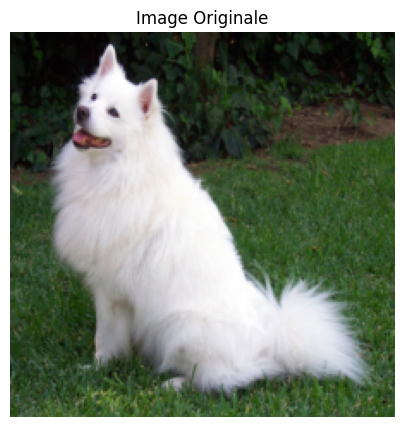

In [4]:
# Télécharger une image d'exemple
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

# Définir les transformations de prétraitement
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Prétraiter l'image
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0).to(device) # Ajouter la dimension du batch

print(f"Forme du tenseur d'entrée : {input_batch.shape}")

# Fonction auxiliaire pour dé-normaliser et afficher les images plus tard
def imshow(tensor, title=None):
    tensor = tensor.cpu().squeeze(0)
    # Annuler la normalisation pour la visualisation
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)

    img_np = tensor.permute(1, 2, 0).numpy()
    plt.imshow(img_np)
    if title:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(5, 5))
imshow(input_batch[0], "Image Originale")
plt.show()

In [5]:
# Espace réservé pour les cartes de caractéristiques
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

# Enregistrer le hook sur layer4
model.layer4.register_forward_hook(get_activation('layer4'))

# Exécuter une passe avant pour remplir 'activations'
with torch.no_grad():
    output = model(input_batch)

# Obtenir la classe prédite
probabilities = torch.nn.functional.softmax(output[0], dim=0)
predicted_class_idx = torch.argmax(probabilities).item()
print(f"Index de la classe prédite : {predicted_class_idx}")

# Récupérer les cartes de caractéristiques capturées
feature_maps = activations['layer4']
print(f"Forme des cartes de caractéristiques : {feature_maps.shape}")

Index de la classe prédite : 258
Forme des cartes de caractéristiques : torch.Size([1, 2048, 7, 7])


### <span style="color:#1E90FF;">Visualisation des Cartes Brutes</span>

Regardons à quoi ressemblent ces "cartes de caractéristiques" brutes. Ce sont de petites grilles de $7 \times 7$ qui détectent des motifs abstraits dans l'image.


### <span style="color:#1E90FF;">Étapes mathématiques</span>

1. Chaque carte de caractéristiques est une **matrice $7 \times 7$** issue de la convolution sur la couche `layer4`.  
2. La carte i correspond à une fonction $f_i(x)$ qui met en évidence certains motifs dans l'image d'entrée.  
3. L'affichage consiste simplement à mapper chaque valeur de la matrice sur une couleur pour visualiser l'intensité de l'activation.



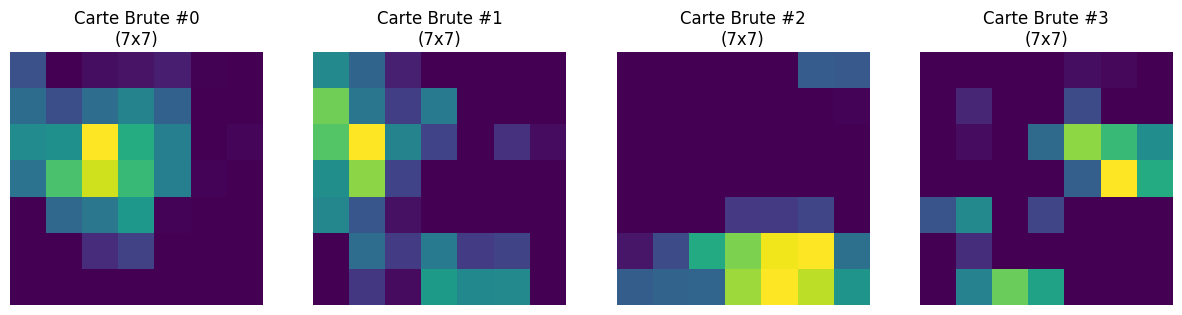

In [6]:
# Visualisons les 4 premières cartes de caractéristiques (canaux 0 à 3)
num_plot = 4
plt.figure(figsize=(15, 4))
for i in range(num_plot):
    plt.subplot(1, num_plot, i+1)
    # On prend la carte i, on la met sur CPU et on la convertit en numpy
    map_raw = feature_maps[0, i].cpu().numpy()
    plt.imshow(map_raw, cmap='viridis')
    plt.title(f"Carte Brute #{i}\n(7x7)")
    plt.axis('off')
plt.show()

### <span style="color:#1E90FF;">Étape 2 : Suréchantillonnage</span>

Les cartes $7 \times 7$ sont trop petites pour masquer l'image $224 \times 224$. Nous devons les agrandir.

**Note technique** : Nous utilisons l'interpolation bilinéaire, standard en vision par ordinateur pour redimensionner les images en douceur.  


### <span style="color:#1E90FF;">Étapes mathématiques</span>

1. Chaque carte de caractéristiques $f_i \in \mathbb{R}^{7 \times 7}$ est redimensionnée pour obtenir $f_i^{\text{up}} \in \mathbb{R}^{224 \times 224}$.  
2. Le suréchantillonnage bilinéaire utilise la formule :  
   $$
   f_i^{\text{up}}(x, y) = \sum_{m,n} w_{mn} \, f_i(m,n)
   $$  
   où $w_{mn}$ sont les poids d'interpolation bilinéaire calculés en fonction de la distance relative à la position $(x, y)$ dans la nouvelle grille.  
3. L’opération conserve les motifs détectés dans chaque carte tout en adaptant leur résolution à celle de l’image d’entrée.


In [7]:
# Suréchantillonner les cartes de caractéristiques à la taille d'entrée (224x224)
# Nous utilisons UpsamplingBilinear2d pour correspondre exactement à la bibliothèque
upsample = torch.nn.UpsamplingBilinear2d(size=(224, 224))
upsampled_maps = upsample(feature_maps)

# Supprimer la dimension du batch -> [2048, 224, 224]
upsampled_maps = upsampled_maps.squeeze(0)
print(f"Forme des cartes suréchantillonnées : {upsampled_maps.shape}")

Forme des cartes suréchantillonnées : torch.Size([2048, 224, 224])


### Visualisation de l'Étape 2 : Cartes Suréchantillonnées

Voyons comment ces mêmes cartes se transforment après avoir été agrandies. Elles deviennent floues car nous avons étiré une petite information sur une grande image.

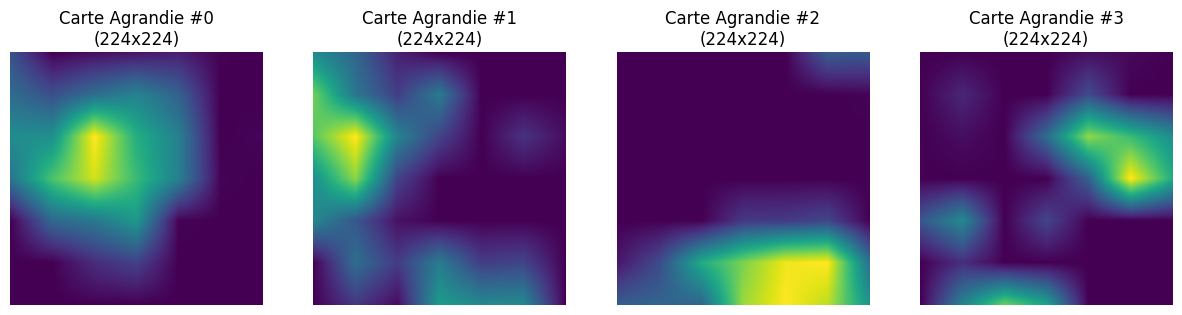

In [8]:
# Visualisons les MÊMES 4 cartes après suréchantillonnage
plt.figure(figsize=(15, 4))
for i in range(num_plot):
    plt.subplot(1, num_plot, i+1)
    map_up = upsampled_maps[i].cpu().numpy()
    plt.imshow(map_up, cmap='viridis')
    plt.title(f"Carte Agrandie #{i}\n(224x224)")
    plt.axis('off')
plt.show()

#### Étape 3 : Normalisation ($s(A^k)$)

Pour utiliser une carte comme "masque", ses valeurs doivent être comprises entre 0 (caché) et 1 (visible).

**Formule** :
$$ s(A^k) = \frac{A^k - \min(A^k)}{\max(A^k) - \min(A^k)} $$
C'est une mise à l'échelle Min-Max.

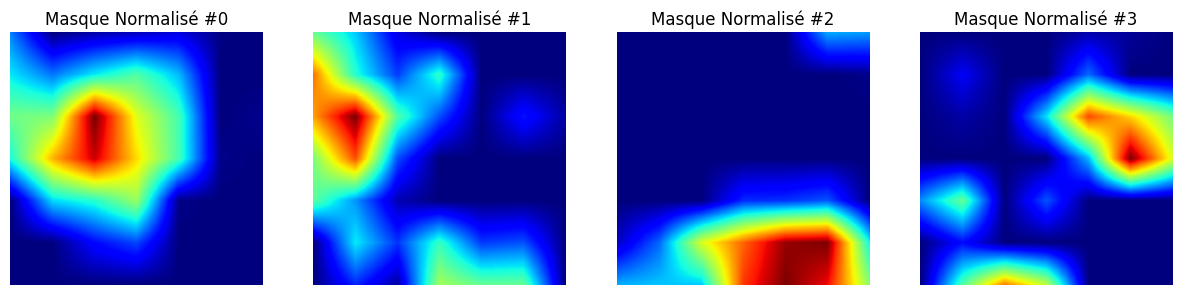

In [9]:
def normalize_maps(maps):
    # forme des maps : [C, H, W]
    # Aplatir les dimensions spatiales pour calculer min/max par canal facilement
    maps_view = maps.view(maps.size(0), -1)

    min_vals = maps_view.min(1, keepdim=True)[0].view(-1, 1, 1)
    max_vals = maps_view.max(1, keepdim=True)[0].view(-1, 1, 1)

    # Éviter la division par zéro (utiliser 1e-8 pour correspondre à la bibliothèque)
    norm_maps = (maps - min_vals) / (max_vals - min_vals + 1e-8)
    return norm_maps

normalized_masks = normalize_maps(upsampled_maps)

# Visualisation de l'Étape 3 : Masques Normalisés
# Regardons encore les mêmes cartes, maintenant normalisées entre 0 et 1
plt.figure(figsize=(15, 4))
for i in range(num_plot):
    plt.subplot(1, num_plot, i+1)
    mask = normalized_masks[i].cpu().numpy()
    plt.imshow(mask, cmap='jet') # Utilisons 'jet' pour mieux voir les zones chaudes/froides
    plt.title(f"Masque Normalisé #{i}")
    plt.axis('off')
plt.show()

#### Étape 4 : Calcul des Scores (L'étape Clé)

C'est ici que Score-CAM se distingue. Nous allons mesurer l'importance de chaque masque **expérimentalement**.

**Procédure** :
1.  On prend l'image originale $X$.
2.  On la multiplie par le masque $M_k$ : $X \circ M_k$.
3.  On passe cette nouvelle image dans le modèle.
4.  On regarde le score (logit) de la classe cible.

Plus le score est élevé, plus cette zone de l'image était importante pour la prédiction.

**Pourquoi c'est mieux que Grad-CAM ?**
Grad-CAM devine l'importance en regardant la pente locale (gradient). Score-CAM mesure l'effet global réel. Si le gradient est nul (saturation), Grad-CAM donne 0. Score-CAM, lui, verra toujours que l'image masquée donne un bon score.


In [10]:
# Nous traiterons par lots pour éviter de manquer de mémoire GPU
scores = []
batch_size = 32
num_channels = normalized_masks.shape[0]

print("Démarrage de la boucle de score...")

with torch.no_grad():
    for i in range(0, num_channels, batch_size):
        # Sélectionner un lot de masques
        batch_masks = normalized_masks[i : i + batch_size]
        current_batch_size = batch_masks.shape[0]

        # Étendre l'image d'entrée pour correspondre à la taille du lot
        batch_input = input_batch.expand(current_batch_size, -1, -1, -1)

        # Appliquer les masques : Entrée * Masque
        masked_input = batch_input * batch_masks.unsqueeze(1)

        # Passe avant
        outputs = model(masked_input)

        # Obtenir les scores pour la classe cible (Logits bruts)
        batch_scores = outputs[:, predicted_class_idx]
        scores.append(batch_scores)

# Concaténer tous les scores
scores = torch.cat(scores)
print(f"Scores calculés pour {len(scores)} canaux.")

Démarrage de la boucle de score...
Scores calculés pour 2048 canaux.


### Visualisation de l'Étape 4 : Inspection des Scores

Regardons concrètement ce qui se passe. Nous allons afficher les **10 cartes les plus importantes** (celles qui ont obtenu les meilleurs scores).

Pour chaque carte, nous montrerons :
1.  Le **Masque** (la carte de caractéristique).
2.  L'**Image Masquée** (ce que le modèle a vu).
3.  Le **Score** (la confiance du modèle pour cette image masquée).

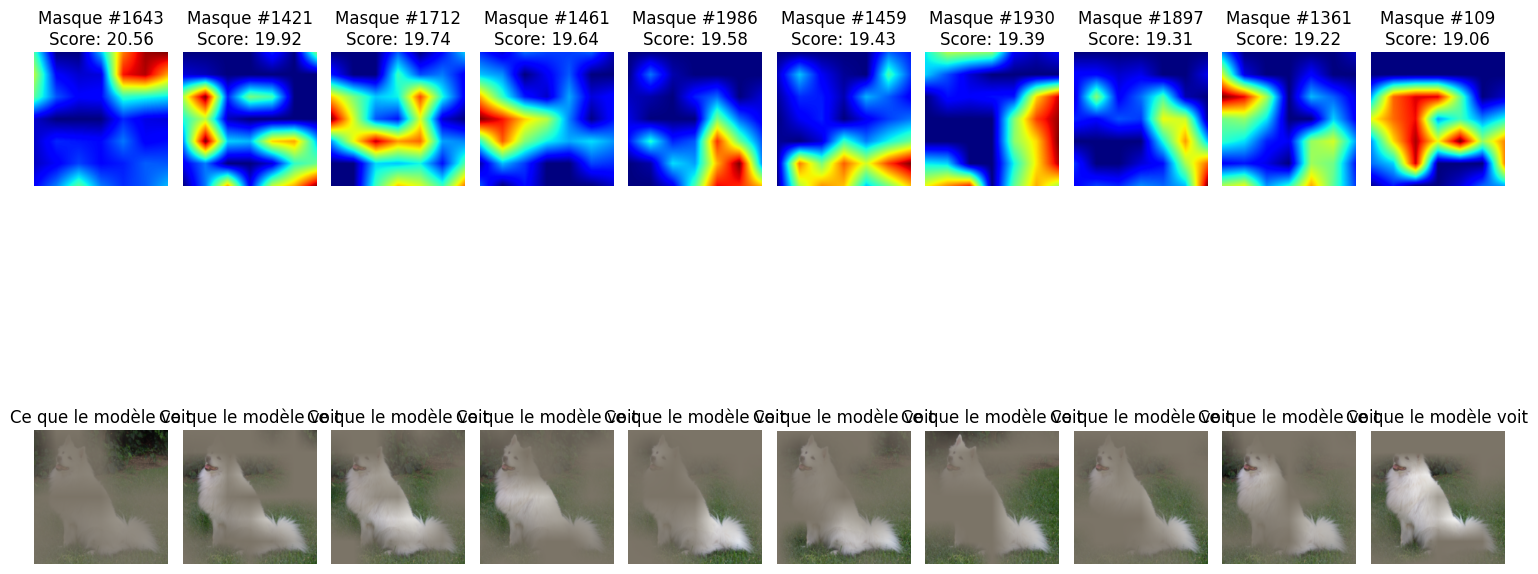

In [15]:
# Trouver les indices des 3 meilleurs scores
top_k = 10
top_scores, top_indices = torch.topk(scores, top_k)

plt.figure(figsize=(15, 10))

for i in range(top_k):
    idx = top_indices[i].item()
    score = top_scores[i].item()

    # Récupérer le masque
    mask = normalized_masks[idx]

    # Créer l'image masquée pour l'affichage
    # (Input * Mask)
    masked_img_tensor = input_batch[0] * mask.unsqueeze(0)

    # Dé-normaliser pour l'affichage
    def unnormalize(tensor):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
        return tensor * std + mean

    masked_img_display = unnormalize(masked_img_tensor).permute(1, 2, 0).cpu().numpy()
    masked_img_display = np.clip(masked_img_display, 0, 1)

    # Affichage Masque
    plt.subplot(2, top_k, i + 1)
    plt.imshow(mask.cpu().numpy(), cmap='jet')
    plt.title(f"Masque #{idx}\nScore: {score:.2f}")
    plt.axis('off')

    # Affichage Image Masquée
    plt.subplot(2, top_k, i + 1 + top_k)
    plt.imshow(masked_img_display)
    plt.title(f"Ce que le modèle voit")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Étape 5 : Agrégation

Nous combinons les cartes en utilisant les scores calculés comme poids.

In [16]:
# Appliquer Softmax aux scores (Normalisation des poids)
weights = torch.nn.Softmax(dim=0)(scores)

# Remodeler les scores pour le broadcasting
weights = weights.view(-1, 1, 1)

# Supprimer la dimension du batch des feature_maps
maps = feature_maps.squeeze(0)

# Combinaison linéaire : Somme(Poids * Carte)
cam = (weights * maps).sum(dim=0)

# Appliquer ReLU (On ne garde que l'influence positive)
cam = F.relu(cam)

# Normaliser la CAM finale à [0, 1]
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-7)

# Redimensionner à la taille de l'image d'entrée
cam = cam.unsqueeze(0).unsqueeze(0)
cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
cam = cam.squeeze().cpu().numpy()

print("CAM générée.")

CAM générée.


## Visualisation Finale

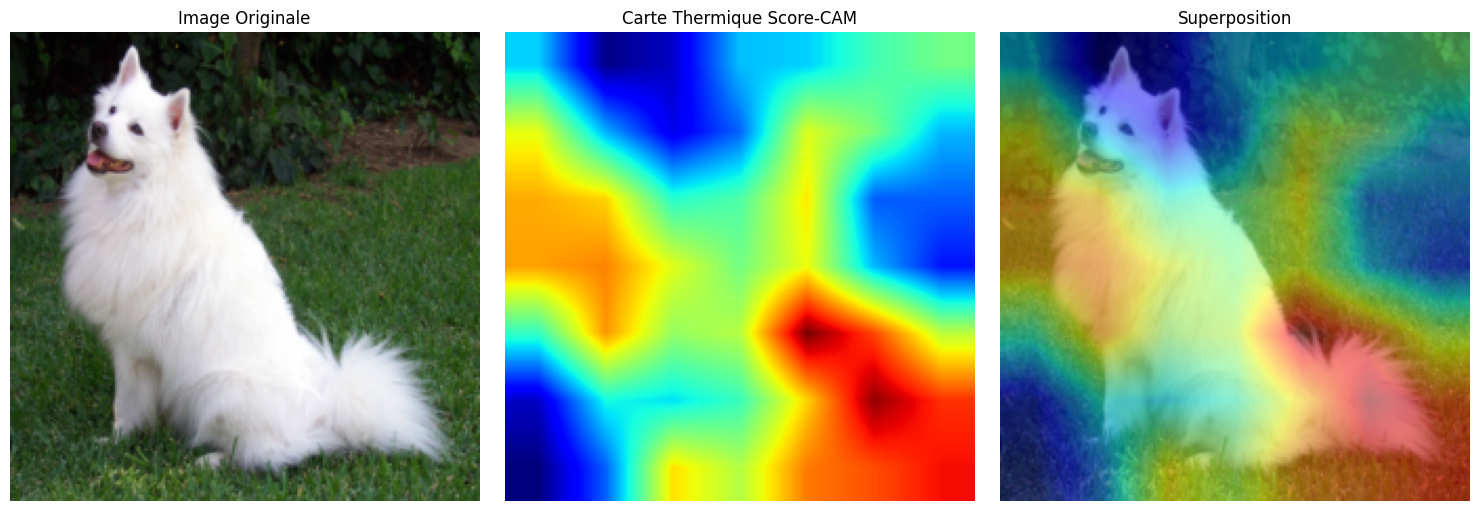

In [17]:
# Préparer l'image pour l'affichage (dé-normalisée)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_tensor = input_batch.cpu().squeeze(0)
img_np = img_tensor.permute(1, 2, 0).numpy()
img_np = img_np * std + mean
img_np = np.clip(img_np, 0, 1)

# Affichage
plt.figure(figsize=(15, 5))

# 1. Originale
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("Image Originale")
plt.axis('off')

# 2. Carte Thermique
plt.subplot(1, 3, 2)
plt.imshow(cam, cmap='jet')
plt.title("Carte Thermique Score-CAM")
plt.axis('off')

# 3. Superposition
plt.subplot(1, 3, 3)
plt.imshow(img_np)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title("Superposition")
plt.axis('off')

plt.tight_layout()
plt.show()

## Bonus : Utiliser la bibliothèque `pytorch-grad-cam`

Voici comment obtenir le même résultat avec la bibliothèque officielle.

100%|██████████| 128/128 [00:06<00:00, 19.67it/s]


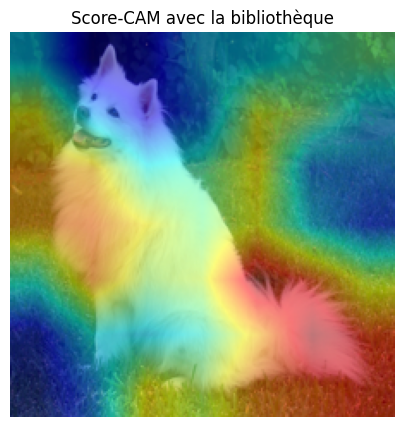

In [14]:
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Définir la couche cible
target_layers = [model.layer4[-1]]

# 2. Initialiser ScoreCAM
cam = ScoreCAM(model=model, target_layers=target_layers)

# 3. Définir la classe cible
targets = [ClassifierOutputTarget(predicted_class_idx)]

# 4. Générer la CAM
grayscale_cam = cam(input_tensor=input_batch, targets=targets)
grayscale_cam = grayscale_cam[0, :]

# 5. Visualiser
rgb_img = np.array(img.resize((224, 224))) / 255.0
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(5, 5))
plt.imshow(visualization)
plt.title("Score-CAM avec la bibliothèque")
plt.axis('off')
plt.show()

<h3 style="color: #8fff1eff; font-weight: bold; text-align: center;">
Interpretation des resultats
</h2>

- Que montre-t-elle ?
Score-CAM : La heatmap se concentre fortement sur la queue, le museau ainsi que le torse.

- Cohérence avec le bon sens ?
✅ Score-CAM : Très cohérent - les parties les plus discriminantes d'un chien sont effectivement sa queue ainsi que son museau

- Surprises ou comportements douteux ?
Heatmap propre, pas de fuite d'importance vers le fond mais pourrait potentiellement manquer des caractéristiques contextuelles utiles dans certains cas.

# 5️⃣ Discussion critique : forces & limites

  **✅ Forces de Score-CAM**
   - Stabilité : N'utilise pas de gradients, donc moins sensible au bruit

   - Robustesse : Évalue l'impact direct des activations sur la prédiction

   - Heatmaps souvent plus localisées et nettes.

   - Interprétabilité : Le score d'importance a une interprétation directe (impact sur la probabilité)

  **❌ Limites de Score-CAM**

   - Coût computationnel : Nécessite de faire une forward pass par carte d'activation

   - Dépendance aux activations : Si une carte est peu informative, Score-CAM peut mal performer.

   - Sélection de la couche : Comme Grad-CAM, elle nécessite de choisir une couche pertinente.

   - Toutes les feature maps n’ont pas le même sens → mélange parfois confus.

   - Pas adapté aux modèles non-visuels (texte, tabulaire, GNN).

  **⚖️ Score-CAM vs Grad-CAM**

   - Grad-CAM : rapide, simple, mais bruité.

   - Score-CAM : plus propre mais beaucoup plus lent.

   - Score-CAM peut être meilleur sur petites images (CIFAR10), mais sur grandes images (ImageNet) → trop lent

  **⚠️ Pièges d'interprétation**

   - Échelle de la heatmap : Les valeurs sont relatives, pas absolues

   - Biais du modèle : Score-CAM montre ce que le modèle utilise, pas nécessairement ce qui est correct

   - Absence de négatifs : Contrairement à certaines méthodes, Score-CAM ne montre pas les régions "contre" la   prédiction


  #### **🔍 Dans quels contextes Score-CAM est utile en pratique ?**
  ✔️ ***Analyse fine de modèles CNN en vision*** : Score-CAM est particulièrement pertinent lorsque l’on veut comprendre  précisément quelles zones d’une image influencent la prédiction. Il est utile pour :

   - valider qu’un modèle détecte bien l’objet principal,

   - repérer des biais visuels (fond, texture),

   - analyser des erreurs étranges du modèle.

   ✔️ ***Contextes à forte exigence d’interprétabilité***

   Dans les domaines où les décisions doivent être justifiées visuellement (santé, sécurité, conduite autonome…),  Score-CAM fournit des heatmaps souvent plus propres et plus localisées que Grad-CAM.

   Exemples :

   - localisation d’une tumeur sur une image médicale,

   - zones de fixation dans un système de détection de piétons,

   - validation d’un modèle de contrôle qualité industriel.

   ✔️ ***Modèles de petite à moyenne taille*** 

   Comme Score-CAM nécessite un forward pass par feature map, il fonctionne mieux sur :

   - des petits CNN (CIFAR-10, MNIST),

   - des images de taille réduite,

   - des tâches à faible latence non critique.

   - Idéal pour des analyses exploratoires en recherche ou en développement.

**⚠️ Dans quels contextes Score-CAM est dangereux à utiliser seul ?**
   ❌ ***Applications en temps réel***

   - Score-CAM est trop coûteux (100–512 forward passes selon la couche).
   - L’utiliser seul pour des décisions en temps réel (voiture autonome, drone, robot…) serait risqué.

   ❌ ***Évaluation d’un modèle très profond***

   Plus la couche a de feature maps, plus Score-CAM :

   - devient lent,

   - devient imprécis (car on mélange un grand nombre de cartes),

   - peut produire des heatmaps "moyennées" qui perdent leur sens.

   - Utiliser Score-CAM seul peut donner une illusion de précision.

   ❌ 3. Interprétation d’un modèle biaisé

   Score-CAM ne détecte pas les biais du modèle — il ne fait que montrer où le modèle regarde.
   S’il regarde au mauvais endroit (ex. le fond ou des artefacts), Score-CAM va l’illustrer… mais ne dira pas que     c’est problématique.

   → On peut surinterpréter des heatmaps trompeuses si on ne combine pas Score-CAM avec une analyse globale du dataset.

  ❌ 4. Tâches complexes nécessitant une justification robuste

   Dans des contextes réglementés (médical, assurance, juridique), utiliser Score-CAM seul serait insuffisant car :

  - la méthode est locale,

  - la stabilité n’est pas parfaite,

  - elle n’explique pas le fonctionnement global du modèle.

  - Elle doit être accompagnée de :

  - SHAP / LIME (explication locale tabulaire/vision),

  - analyse des erreurs,

  - validation humaine

# 6️⃣ Conclusion & points à retenir
**🎯 Points clés**
  - Score-CAM est une alternative stable à Grad-CAM qui évalue l'impact direct des cartes de caractéristiques

  - Méthode par perturbation : Mesure l'effet de masquage sur la prédiction

  - Applicable aux CNN : Pour comprendre les décisions sur des images

  - Plus coûteux mais plus stable que les approches par gradients

  - Utiliser avec précaution : Toujours valider avec d'autres méthodes XAI

**🚀 Extensions possibles**
  - Score-CAM++ : Variante avec normalisation améliorée

  - Combinaison avec d'autres méthodes : Utiliser Score-CAM avec LIME pour explications hiérarchiques

  - Application à d'autres architectures : Adapté aux transformers vision (ViT)

# 7️⃣ Références
  - Implémentation GitHub : https://github.com/haofanwang/Score-CAM
  - TorchCAM : https://github.com/frgfm/torch-cam

  - Documentation : https://captum.ai/